# Bag of Visual Words demo

This notebook trains and evaluates a Bag of Visual Words classifier on the provided image dataset.

You can switch the feature extractor by changing the `feature_extractor` variable in the next code cell. Supported options include `SIFT`, `SURF` when available, `ORB`, `AKAZE`, `BRISK`, and `KAZE`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bovw import BagOfVisualWordsClassifier, BoVWConfig

plt.rcParams['figure.dpi'] = 120

In [2]:
dataset_root = Path('images_all_reduced')
feature_extractor = 'SIFT'  # change to ORB, AKAZE, BRISK, KAZE, or SURF if available
vocabulary_size = 128

config = BoVWConfig(
    feature_extractor=feature_extractor,
    vocabulary_size=vocabulary_size,
    max_descriptors_per_image=250,
    max_vocabulary_descriptors=20000,
    random_state=42,
)
model = BagOfVisualWordsClassifier(config)
model.supported_extractors()

['SIFT', 'SURF', 'ORB', 'AKAZE', 'BRISK', 'KAZE']

In [3]:
model.fit(dataset_root / 'train')
metrics = model.evaluate(dataset_root / 'test')
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(metrics['classification_report'])

Accuracy: 0.6522
              precision    recall  f1-score   support

   accordion       0.77      0.91      0.83        11
   airplanes       1.00      0.80      0.89        10
      anchor       0.38      0.38      0.38         8
         ant       0.62      0.62      0.62         8
      barrel       0.44      0.44      0.44         9

    accuracy                           0.65        46
   macro avg       0.64      0.63      0.63        46
weighted avg       0.66      0.65      0.65        46



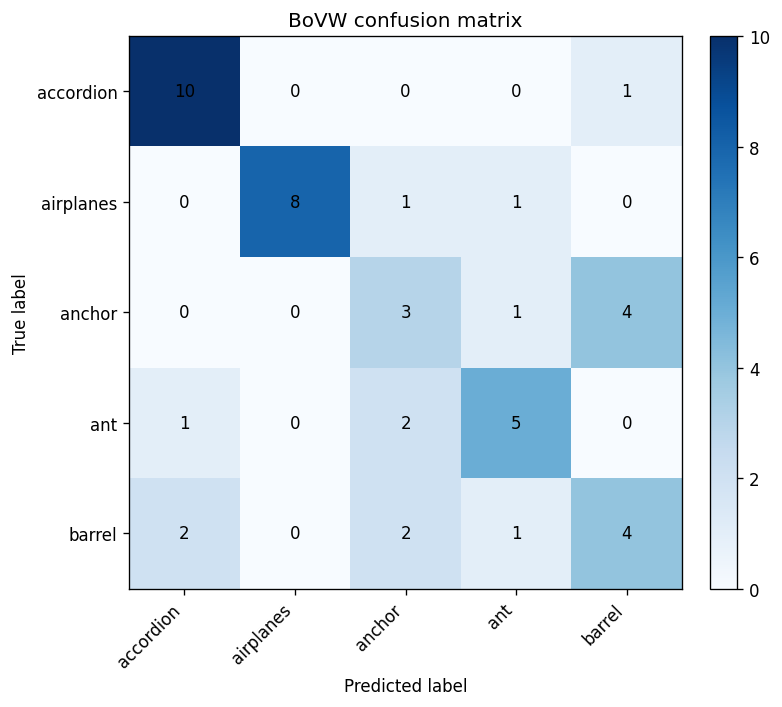

In [4]:
confusion = metrics['confusion_matrix']
labels = model.class_names

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('BoVW confusion matrix')

for row in range(confusion.shape[0]):
    for col in range(confusion.shape[1]):
        ax.text(col, row, int(confusion[row, col]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

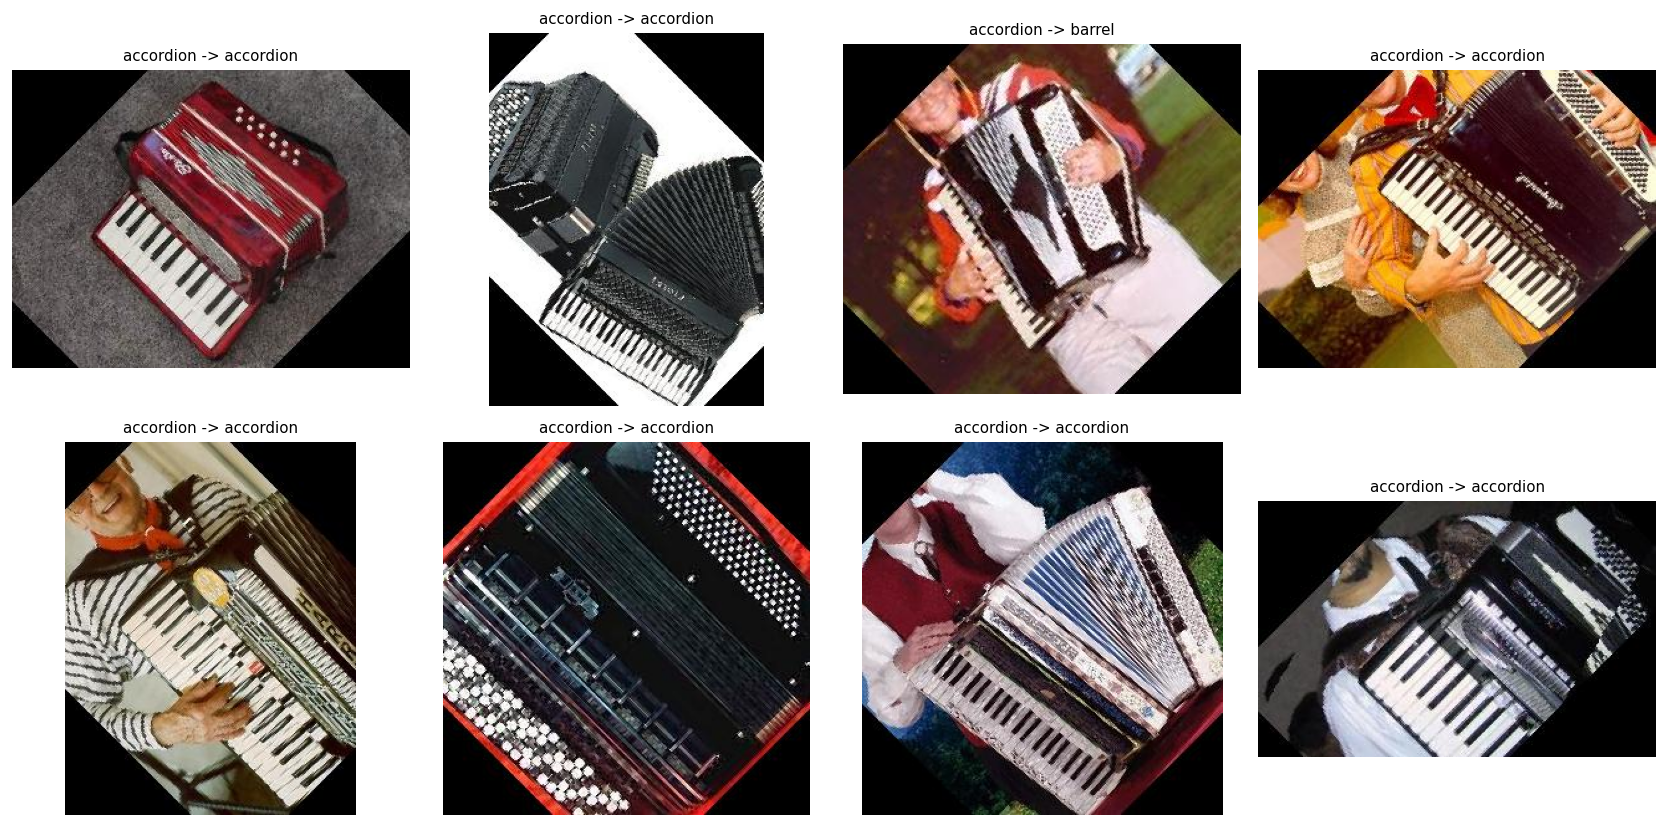

In [5]:
test_paths = metrics['image_paths']
y_true = metrics['y_true']
y_pred = metrics['y_pred']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, image_path, truth, pred in zip(axes, test_paths[:8], y_true[:8], y_pred[:8]):
    image = plt.imread(str(image_path))
    if image.ndim == 2:
        ax.imshow(image, cmap='gray')
    else:
        ax.imshow(image)
    ax.set_title(f'{truth} -> {pred}', fontsize=9)
    ax.axis('off')

for ax in axes[len(test_paths[:8]):]:
    ax.axis('off')

plt.tight_layout()
plt.show()